In [1]:
import json
import math
import os
import random
import re
import warnings
from importlib.util import find_spec
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from qwen_vl_utils import process_vision_info
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from tqdm.auto import tqdm
from transformers import AutoProcessor, GenerationConfig, Qwen2VLForConditionalGeneration
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
from torchmetrics.functional.image import (
    peak_signal_noise_ratio,
    structural_similarity_index_measure,
)

In [ ]:
# ---------------------------- Experiment settings ----------------------------
SEED = 42
VERBOSE = 2

# Bias field
EPSILON = 0.3
CONTROL_POINT_SPACING = (32, 32)
DOWNSCALE = 2
INTERPOLATION_ORDER = 3
SPACE = "log"

# Attack
NUM_STEPS = 10
STEP_SIZE = 0.1
LOSS_TYPE = "cross_entropy"     # Options: "cross_entropy", "kl"

# Path
MODEL_PATH = "JZPeterPan/MedVLM-R1"
HF_CACHE = "/data/huggingface_cache"
OUTPUT_DIRECTORY = Path("result/MedVLM-R1/bf")

In [3]:
def find_project_root(start=Path.cwd(), project_name="attack-on-medvqa"):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if path.name == project_name:
            return path
    raise FileNotFoundError(f"Could not find project root named {project_name!r}")


PROJECT_ROOT = find_project_root()
SAMPLE_ROOT = PROJECT_ROOT / "data" / "OmniMedVQA" / "sample"
QUESTION_PATH = SAMPLE_ROOT / "question.json"
OUTPUT_DIRECTORY = PROJECT_ROOT / OUTPUT_DIRECTORY
ATTACKED_IMAGE_DIRECTORY = OUTPUT_DIRECTORY / "attacked_images"
BIAS_FIELD_DIRECTORY = OUTPUT_DIRECTORY / "bias_fields"

for directory in (OUTPUT_DIRECTORY, ATTACKED_IMAGE_DIRECTORY, BIAS_FIELD_DIRECTORY):
    directory.mkdir(parents=True, exist_ok=True)

with QUESTION_PATH.open(encoding="utf-8") as file:
    all_samples = json.load(file)

mri_samples = [sample for sample in all_samples if sample.get("modality") == "MRI"]
print(f"Loaded {len(mri_samples)} MRI samples out of {len(all_samples)} total samples.")

Loaded 1 MRI samples out of 1 total samples.


In [4]:
os.environ["HF_HOME"] = HF_CACHE

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"
print(f"Using device: {device}")

flash_attn_available = find_spec("flash_attn") is not None
attn_implementation = "flash_attention_2" if flash_attn_available else "sdpa"
print(f"Using attention implementation: {attn_implementation}")

dtype = torch.bfloat16 if cuda_available else torch.float32
print(f"Using dtype: {dtype}")
computation_dtype = torch.float32

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=dtype,
    attn_implementation=attn_implementation,
    device_map="auto",
)
model.eval()
model.requires_grad_(False)
model.config.use_cache = False

processor = AutoProcessor.from_pretrained(MODEL_PATH)
image_processor = processor.image_processor

generation_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,
    num_return_sequences=1,
    pad_token_id=151643,
)

print("Model and processor loaded successfully.")

Using device: cuda
Using attention implementation: sdpa
Using dtype: torch.bfloat16


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Model and processor loaded successfully.


In [5]:
QUESTION_TEMPLATE = """
    {Question}
    Your task:
    1. Think through the question step by step, enclose your reasoning process in <think>...</think> tags.
    2. Then provide the correct single-letter choice (A, B, C, D,...) inside <answer>...</answer> tags.
    3. No extra information or text outside of these tags.
    """

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def extract_answer(output_text, tag="answer"):
    match = re.search(rf"<{tag}>\s*(.*?)\s*</{tag}>", output_text, re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else None

def load_image_tensor(image_path):
    image = read_image(image_path).float() / 255.0

    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)
    if image.shape[0] > 3:
        image = image[:3]
        
    image = image.clamp(0,1)
    image = image.to(device=device)
    return image
    
def tensor_to_pil(image_tensor):
    if image_tensor.ndim == 4 and image_tensor.shape[0] == 1:
        image_tensor = image_tensor.squeeze(0)
    return to_pil_image(image_tensor.detach().cpu().float().clamp(0, 1))

def get_image_info(image_tensor):
    patch_size = image_processor.patch_size
    merge_size = image_processor.merge_size
    resized_h, resized_w = smart_resize(
        image_tensor.shape[-2],
        image_tensor.shape[-1],
        factor=patch_size * merge_size,
        min_pixels=image_processor.size["shortest_edge"],
        max_pixels=image_processor.size["longest_edge"],
    )
    
    grid_t = 1
    grid_h = resized_h // patch_size
    grid_w = resized_w // patch_size
    
    image_grid_thw = torch.tensor(
        [[grid_t, grid_h, grid_w]],
        device=image_tensor.device,
        dtype=torch.long,
    )
    
    return resized_h, resized_w, image_grid_thw


def process_image(image_tensor, resized_h, resized_w):
    patch_size = image_processor.patch_size
    merge_size = image_processor.merge_size
    temporal_patch_size = image_processor.temporal_patch_size

    image = F.interpolate(
        image_tensor.unsqueeze(0),
        size=(resized_h, resized_w),
        mode="bicubic",
        align_corners=False,
    ).clamp(0, 1)

    # Normalize
    mean = image.new_tensor(image_processor.image_mean).view(1, 3, 1, 1)
    std = image.new_tensor(image_processor.image_std).view(1, 3, 1, 1)
    patches = (image - mean) / std

    # Temporal patch
    remainder = patches.shape[0] % temporal_patch_size
    if remainder != 0:
        repeat_count = temporal_patch_size - remainder
        patches = torch.cat([patches, patches[-1:].repeat(repeat_count, 1, 1, 1)], dim=0)

    # Grid size
    channels = patches.shape[1]
    grid_t = patches.shape[0] // temporal_patch_size
    grid_h = resized_h // patch_size
    grid_w = resized_w // patch_size
    
    patches = patches.reshape(
        grid_t, temporal_patch_size, channels,
        grid_h // merge_size, merge_size, patch_size,
        grid_w // merge_size, merge_size, patch_size,
    )
    
    patches = patches.permute(0, 3, 6, 4, 7, 2, 1, 5, 8)
    
    return patches.reshape(
        grid_t * grid_h * grid_w,
        channels * temporal_patch_size * patch_size * patch_size,
    )

def build_attack_input(tensor_image, problem, target):
    
    if tensor_image.ndim == 4:
        tensor_image = tensor_image.squeeze(0)

    message = [{
        "role": "user",
        "content": [
            {"type": "image", "image": "file://placeholder.png"},
            {"type": "text", "text": QUESTION_TEMPLATE.format(Question=problem)},
        ],
    }]

    prompt_text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    target_text = f"<answer>{target}</answer>"

    inputs = processor(
        text=[prompt_text + target_text],
        images=[tensor_to_pil(tensor_image)],
        padding=True,
        return_tensors="pt",
    ).to(device)
    
    target_ids = processor.tokenizer(
            target_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).input_ids.to(device)
      
    target_len = target_ids.size(1)
    labels = torch.full_like(inputs.input_ids, -100)
    labels[:, -target_len:] = inputs.input_ids[:, -target_len:]
    return inputs, labels


def run_model(question, image):
    
    if isinstance(image, (str, Path)):
        image_source = Path(image).resolve().as_uri()
    elif isinstance(image, torch.Tensor):
        image_source = tensor_to_pil(image)
    
    message = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_source},
            {"type": "text", "text": QUESTION_TEMPLATE.format(Question=question)},
        ],
    }]
    
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True) 
    image_inputs, video_inputs = process_vision_info(message)
    
    inputs_adv = processor(
        text=text,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(device)
    
    generated_ids = model.generate(**inputs_adv, use_cache=True, max_new_tokens=1024, do_sample=False, generation_config=generation_config)
    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs_adv.input_ids, generated_ids)]
    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
    
    return output_text[0] 

In [6]:
def bspline(spacing, order=INTERPOLATION_ORDER):
    
    # Validation checks
    if len(spacing) != 2:
        raise ValueError("spacing must contain two values: (height, width).")
    
    spacing_height, spacing_width = map(int, spacing)
    
    if spacing_height < 1 or spacing_width < 1:
        raise ValueError("Spacing values must be at least 1.")
    
    if order < 1:
        raise ValueError("B-spline order must be at least 1.")
    
    # Initialize kernel
    mean_kernel = torch.ones(1,1, spacing_height, spacing_width, device=device, dtype=computation_dtype)
    kernel = mean_kernel.clone()
    normalization = spacing_height * spacing_width
    
    # Iterative convolution
    
    for iteration in range(1, order + 1):
        padding = (iteration * spacing_height, iteration * spacing_width)
        kernel = F.conv2d(kernel, mean_kernel, padding=padding)
        kernel /= normalization
    
    return kernel

def generate_bias_field(image_tensor, control_points=None):
    
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    # Validation checks
    if image_tensor.ndim != 4:
        raise ValueError("image_tensor must have shape [batch_size, channels, height, width] or [channels, height, width].")
    
    if not 0 <= EPSILON < 1:
        raise ValueError("EPSILON must be within [0, 1).")
    
    if DOWNSCALE < 1:
        raise ValueError("DOWNSCALE must be at least 1.")
        
    batch_size, channels, height, width = image_tensor.shape
    
    # Downscale image
    low_resolution_height = max(1, math.ceil(height / DOWNSCALE))
    low_resolution_width = max(1, math.ceil(width / DOWNSCALE))
    
    # Control point spacing
    spacing_height = max(1, CONTROL_POINT_SPACING[0] // DOWNSCALE)
    spacing_width = max(1, CONTROL_POINT_SPACING[1] // DOWNSCALE)
    spacing = (spacing_height, spacing_width)
    
    # Bound
    if SPACE == "log":
        lower_bound = math.log(1.0 - EPSILON)
        upper_bound = math.log(1.0 + EPSILON)

    elif SPACE == "linear":
        lower_bound = -EPSILON
        upper_bound = EPSILON
        
    else:
        raise ValueError(f"Unsupported SPACE: {SPACE}. Use 'log' or 'linear'.")
    
    # Control points initialization
    if control_points is None:
        control_points_height = math.ceil(low_resolution_height / spacing_height) + 2
        control_points_width = math.ceil(low_resolution_width / spacing_width) + 2
        control_points_shape = (batch_size, 1, control_points_height, control_points_width)
        
        control_points = torch.empty(control_points_shape, device=device, dtype=computation_dtype).uniform_(lower_bound, upper_bound)
        control_points.requires_grad_(True)
        if VERBOSE > 1:
            print(f"Control points initialized : {control_points_height * control_points_width}.")

    else:
        if control_points.ndim != 4:
            raise ValueError("control_points must have shape [B, 1, Hcp, Wcp].")

        if control_points.shape[0] != batch_size:
            raise ValueError("The control-point batch size must match the image batch size.")

    # Bspline interpolation
    bspline_kernel = bspline(
        spacing=spacing,
        order=INTERPOLATION_ORDER,
    )
    padding = ((bspline_kernel.shape[-2] - 1) // 2, (bspline_kernel.shape[-1] - 1) // 2)

    interpolated_field = F.conv_transpose2d(
        control_points,
        bspline_kernel,
        stride=spacing,
        padding=padding,
    )

    # Crop at the center
    crop_start_h = (interpolated_field.shape[-2] - low_resolution_height) // 2
    crop_start_w = (interpolated_field.shape[-1] - low_resolution_width) // 2
    low_resolution_field = interpolated_field[
        :,
        :,
        crop_start_h : crop_start_h + low_resolution_height,
        crop_start_w : crop_start_w + low_resolution_width,
    ]
    
    # Upscale to original image size
    upscaled_field = F.interpolate(
        low_resolution_field,
        size=(height, width),
        mode="bilinear",
        align_corners=False,
    )
    
    if SPACE == "log":
        bias_field = upscaled_field.exp()
    else:
        bias_field = 1.0 + upscaled_field
        
    # Clamp
    bias_field = bias_field.clamp(1.0 - EPSILON, 1.0 + EPSILON)
    
    # Conversion
    bias_field = bias_field.to(device=device, dtype=dtype)
    
    # Expand to other channels if necessary
    if channels > 1:
        bias_field = bias_field.expand(-1, channels, -1, -1,)
        
    return control_points, bias_field

def plot_bias_field_result(image, bias_field, biased_image):
    
    # Remove batch dimension if present
    if image.ndim == 4:
        image = image.squeeze(0)
    if bias_field.ndim == 4:
        bias_field = bias_field.squeeze(0)
    if biased_image.ndim == 4:
        biased_image = biased_image.squeeze(0)
        
    image = image.detach().cpu().float()
    bias_field = bias_field.detach().cpu().float()
    biased_image = biased_image.detach().cpu().float()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image[0], cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    bias_plot = axes[1].imshow(bias_field[0], cmap="jet")
    axes[1].set_title("Bias Field")
    axes[1].axis("off")
    fig.colorbar(bias_plot, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(biased_image[0], cmap="gray")
    axes[2].set_title("Image × Bias Field")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
    
def eval_image(image1, image2):
    if image1.ndim == 3:
        image1 = image1.unsqueeze(0)

    if image2.ndim == 3:
        image2 = image2.unsqueeze(0)

    if image1.shape != image2.shape:
        raise ValueError(
            f"Shape mismatch: image1={image1.shape}, image2={image2.shape}")

    # Use float32 for stable metric calculation
    image1 = image1.detach().float()
    image2 = image2.detach().float()

    mse = F.mse_loss(image2, image1)

    psnr = peak_signal_noise_ratio(
        image2,
        image1,
        data_range=1.0,
    )

    ssim = structural_similarity_index_measure(
        image2,
        image1,
        data_range=1.0,
    )

    return {
        "mse": mse.item(),
        "psnr": psnr.item(),
        "ssim": ssim.item(),
    }

In [7]:
def compute_loss(image, inputs, labels, loss_type=LOSS_TYPE, clean_probs=None):
    
        if image.ndim == 4:
            if image.shape[0] != 1:
                raise ValueError("Only batch size 1 is currently supported.")
            image = image.squeeze(0)
        if image.ndim != 3:
            raise ValueError("image must have shape [C, H, W] or [1, C, H, W].")

        if image.shape[0] != 3:
            raise ValueError("MedVLM-R1 expects a three-channel RGB image.")
        
        resized_h, resized_w, image_grid_thw = get_image_info(image)
        pixel_values = process_image(image, resized_h, resized_w).to(device=device, dtype=dtype)
        
        model_inputs = {
            key: value
            for key, value in inputs.items()
            if key not in {
                "pixel_values",
                "pixel_values_videos",
                "image_grid_thw",
                "labels",
            }
        }
        model_inputs["pixel_values"] = pixel_values
        model_inputs["image_grid_thw"] = image_grid_thw.to(device)
        
        labels = labels.to(device)
        
        outputs = model(**model_inputs, labels=labels, use_cache=False, return_dict=True)
        
        # loss = outputs.loss
        
        logits = outputs.logits
        
        selected_logits, selected_labels = select_labelled_tokens(logits, labels)
        
        if loss_type == "cross_entropy":
            loss = F.cross_entropy(
                input=selected_logits.float(),
                target=selected_labels
                )
            
        elif loss_type == "kl":
            if clean_probs is None:
                raise ValueError("KL loss requires clean_probs.")
            
            log_probs = F.log_softmax(selected_logits.float(), dim=-1)
            loss = F.kl_div(
                input=log_probs,
                target=clean_probs,
                reduction="batchmean" # See https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.kl_div.html
                )
            
        else:
            raise ValueError(
                f"Unsupported loss type: {loss_type}"
            )
            

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Untargeted loss is not finite: {loss.item()}"
            )
        if not loss.requires_grad:
            raise RuntimeError("The loss has no gradient")
        
        return loss
    
def select_labelled_tokens(logits, labels):
    
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    
    labelled_mask = shift_labels != -100
    selected_logits = shift_logits[labelled_mask]
    selected_labels = shift_labels[labelled_mask]
    
    token_ids = selected_labels.detach().cpu().tolist()
    print(f"Selected token IDs : {token_ids}")
    for id in token_ids:
        decoded_token = processor.tokenizer.decode([id], skip_special_tokens=False)
        print(f"Token ID: {id}, Decoded Token: {decoded_token}")
    
    # print(f"Selected tokens : {processor.tokenizer.convert_ids_to_tokens(token_ids)}")
    # print(f"Decoded selected tokens : {processor.tokenizer.decode(token_ids, skip_special_tokens=False)}")
    
    return selected_logits, selected_labels

In [8]:
def attack_bf(image, problem, target, num_steps=NUM_STEPS, step_size=STEP_SIZE):

    if image.ndim == 3:
        image = image.unsqueeze(0)

    if image.ndim != 4:
        raise ValueError("image must have shape [C, H, W] or [B, C, H, W].")

    # Detach image from computation graph
    image = image.detach().to(device=device, dtype=computation_dtype)
    
    # Build attack inputs and labels
    inputs, labels = build_attack_input(
        tensor_image=image,
        problem=problem,
        target=target,
    )
    
    
    
    labelled_ids = labels[labels != -100]
    labelled_text = processor.tokenizer.decode(
        labelled_ids.detach().cpu().tolist(),
        skip_special_tokens=False,
    )

    print("\n========== LOSS TARGET ==========")
    print(f"Token IDs: {labelled_ids.tolist()}")
    print(f"Decoded target: {repr(labelled_text)}")
    print("=================================")
    
    

    # Initialize control points and bias field
    control_points, bias_field = generate_bias_field(image_tensor=image, control_points=None)
    
    biased_image = (image * bias_field).clamp(0, 1)
    print("Initial randomized bias field")
    plot_bias_field_result(image, bias_field, biased_image)

    history = []

    for step in range(num_steps):
        
        # Restart computation graph
        control_points = control_points.detach().requires_grad_(True)

        # Generate bias field
        _, bias_field = generate_bias_field(image_tensor=image, control_points=control_points)

        adversarial_image = (image * bias_field).clamp(0, 1)

        # Calculate the correct-answer loss.
        loss = compute_loss(
            image=adversarial_image,
            inputs=inputs,
            labels=labels,
        )
        
        # Clear gradients
        model.zero_grad(set_to_none=True)
        
        # Backpropagation
        loss.backward()
        gradient = control_points.grad
        if gradient is None:
            raise RuntimeError("No gradient reached the control points.")

        # Normalize gradient
        normalized_gradient = gradient / (gradient.norm(p=2) + 1e-12)

        # Decaying step size
        # step_size =/ math.sqrt(step + 1)

        # Gradient ascent
        with torch.no_grad():
            control_points = (control_points + step_size * normalized_gradient)

            if SPACE == "log":
                lower_bound = math.log(1.0 - EPSILON)
                upper_bound = math.log(1.0 + EPSILON)
            else:
                lower_bound = -EPSILON
                upper_bound = EPSILON

            control_points = control_points.clamp(lower_bound, upper_bound)

        history.append({
            "step": step + 1,
            "loss": loss.item(),
            "gradient_mean": gradient.abs().mean().item(),
            "step_size": step_size,
        })

        print(
            f"Step {step + 1:02d} | "
            f"Loss: {loss.item():.6f} | "
            f"Gradient mean: {gradient.abs().mean().item():.6e}"
        )

    # Detach from computation graph
    control_points = control_points.detach()

    with torch.no_grad():
        _, final_bias_field = generate_bias_field(
            image_tensor=image,
            control_points=control_points,
        )

        final_image = (
            image * final_bias_field
        ).clamp(0, 1)

    return (
        final_image,
        final_bias_field,
        control_points,
        history,
    )

In [9]:
# # Running once
# sample = mri_samples[0]

# image_path = SAMPLE_ROOT / sample["image"][0]
# image = load_image_tensor(image_path)

# problem = sample["problem"]
# solution = sample["solution"]

# adv_image, bias_field, control_points, history = attack_bf(
#     image=image,
#     problem=problem,
#     target=solution
# )

# print(history)

MRI VQA tasks:   0%|          | 0/1 [00:00<?, ?it/s]


Processing sample 1/1: ID=mod-mri:000000


`generation_config` default values have been modified to match model-specific defaults: {'do_sample': True, 'use_cache': None, 'temperature': 0.01, 'top_k': 1, 'top_p': 0.001, 'bos_token_id': 151643, 'eos_token_id': [151645, 151643], 'attn_implementation': 'flash_attention_2'}. If this is not desired, please set these values explicitly.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



========== CLEAN MODEL OUTPUT ==========
'<think>\n    The image appears to be a cross-sectional view of a human body, likely obtained using an MRI (Magnetic Resonance Imaging) scan. MRI scans are commonly used to visualize internal structures of the body, including bones, muscles, and soft tissues.\n</think>\n\n<answer>B</answer>'
Extracted clean answer: B

========== LOSS TARGET ==========
Token IDs: [27, 9217, 36721, 522, 9217, 29]
Decoded target: '<answer>B</answer>'
Control points initialized : 81.
Initial randomized bias field


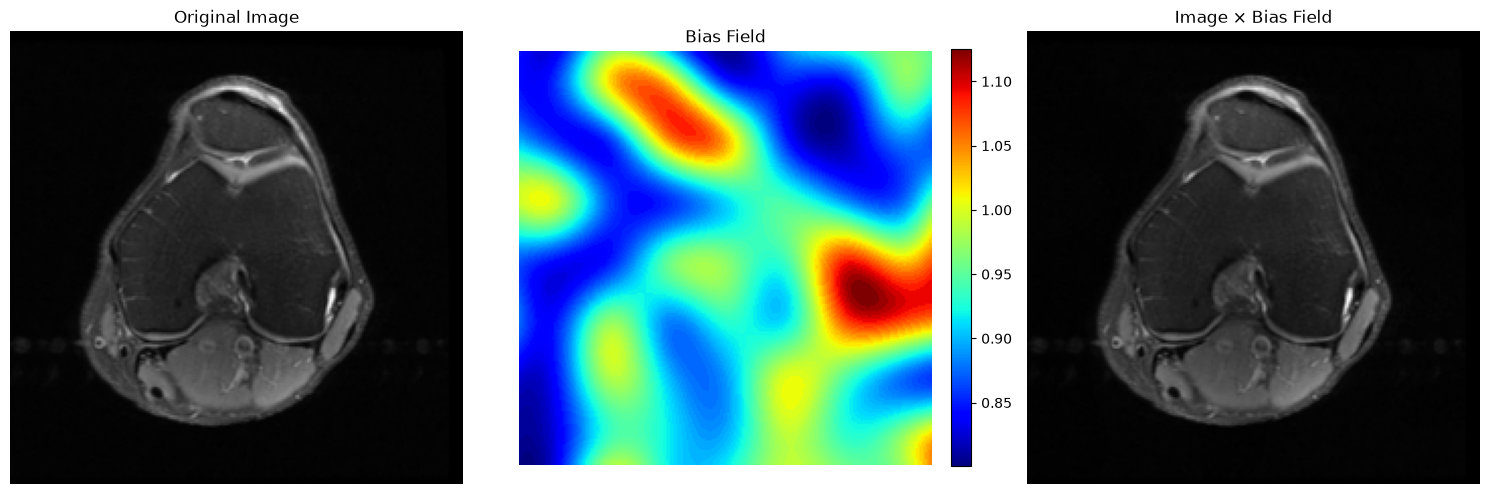

Selected token IDs : [27, 9217, 36721, 522, 9217, 29]
Token ID: 27, Decoded Token: <
Token ID: 9217, Decoded Token: answer
Token ID: 36721, Decoded Token: >B
Token ID: 522, Decoded Token: </
Token ID: 9217, Decoded Token: answer
Token ID: 29, Decoded Token: >
Step 01 | Loss: 2.121012 | Gradient mean: 2.034890e-02
Selected token IDs : [27, 9217, 36721, 522, 9217, 29]
Token ID: 27, Decoded Token: <
Token ID: 9217, Decoded Token: answer
Token ID: 36721, Decoded Token: >B
Token ID: 522, Decoded Token: </
Token ID: 9217, Decoded Token: answer
Token ID: 29, Decoded Token: >
Step 02 | Loss: 2.193932 | Gradient mean: 6.773643e-03
Selected token IDs : [27, 9217, 36721, 522, 9217, 29]
Token ID: 27, Decoded Token: <
Token ID: 9217, Decoded Token: answer
Token ID: 36721, Decoded Token: >B
Token ID: 522, Decoded Token: </
Token ID: 9217, Decoded Token: answer
Token ID: 29, Decoded Token: >
Step 03 | Loss: 2.173232 | Gradient mean: 9.448955e-03
Selected token IDs : [27, 9217, 36721, 522, 9217, 29]
T

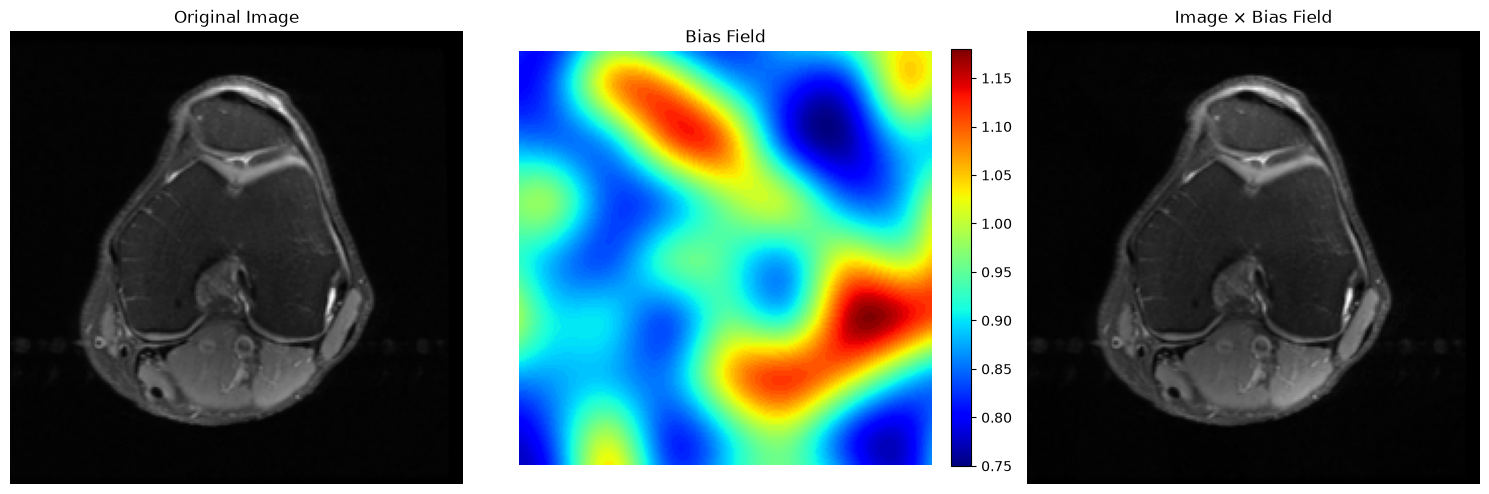


Finished


[{'question_id': 'mod-mri:000000',
  'correct_answer': 'B',
  'adversarial_answer': 'B',
  'attack_success': False,
  'steps': 100,
  'loss_history': [2.121011734008789,
   2.1939315795898438,
   2.173232316970825,
   2.191596746444702,
   2.167525053024292,
   2.1101343631744385,
   2.1353471279144287,
   2.1667215824127197,
   2.146242141723633,
   2.1210083961486816,
   2.1672885417938232,
   2.1468331813812256,
   2.1611719131469727,
   2.1809585094451904,
   2.146167516708374,
   2.168297290802002,
   2.1725242137908936,
   2.155207872390747,
   2.191850423812866,
   2.1727943420410156,
   2.201812505722046,
   2.1717865467071533,
   2.168346881866455,
   2.2214858531951904,
   2.1896660327911377,
   2.168229818344116,
   2.172093629837036,
   2.184570550918579,
   2.145418882369995,
   2.16123366355896,
   2.184934139251709,
   2.1259210109710693,
   2.188490867614746,
   2.1793649196624756,
   2.1640779972076416,
   2.146000623703003,
   2.143587112426758,
   2.1466150283813477,

In [10]:
set_seed(SEED)

attack_results = []

for sample_index, sample in enumerate(tqdm(mri_samples, desc="MRI VQA tasks")):
    question_id = str(sample["id"])
    image_path = SAMPLE_ROOT / sample["image"][0]

    image = load_image_tensor(image_path)
    problem = sample["problem"]
    solution = sample["solution"]

    if VERBOSE:
        print(f"\nProcessing sample {sample_index + 1}/{len(mri_samples)}: ID={question_id}")

    clean_output = run_model(problem, image_path)
    clean_answer = extract_answer(clean_output, tag="answer")
    
    
    
    print("\n========== CLEAN MODEL OUTPUT ==========")
    print(repr(clean_output))
    print("========================================")
    print(f"Extracted clean answer: {clean_answer}")
    
    
    
    
    adversarial_image, final_bias_field, optimized_control_points, attack_history = attack_bf(
        image=image,
        problem=problem,
        target=solution,
        num_steps=100,
        step_size=0.05
        )

    # # attack_bf() returns batched tensors [1, C, H, W].
    # adversarial_image_for_eval = adversarial_image.squeeze(0)
    # final_bias_field_for_plot = final_bias_field.squeeze(0)

    image_loss = eval_image(image, adversarial_image)

    adversarial_output = run_model(problem, adversarial_image)
    adversarial_answer = extract_answer(adversarial_output, tag="answer")
    
    
    
    
    print("\n======= ADVERSARIAL MODEL OUTPUT =======")
    print(repr(adversarial_output))
    print("========================================")
    print(f"Extracted adversarial answer: {adversarial_answer}")
    
    
    
    
    valid_answers = {"A", "B", "C", "D"}
    attack_success = (adversarial_answer in valid_answers) and (adversarial_answer != solution)

    if VERBOSE:
        print(f"Attack successful: {attack_success}")
        if VERBOSE > 1:
            print(f"Problem: {problem}")
            print(f"Solution: {solution}")
            print(f"Model answer (clean): {clean_answer}")
            print(f"Model answer (adversarial): {adversarial_answer}")
            print("Image evaluation metrics after attack:")
            print(f"  MSE: {image_loss['mse']:.6f}")
            print(f"  PSNR: {image_loss['psnr']:.2f} dB")
            print(f"  SSIM: {image_loss['ssim']:.4f}")
            plot_bias_field_result(image, final_bias_field, adversarial_image)


    attack_results.append({
        "question_id": question_id,
        "correct_answer": solution,
        "adversarial_answer": adversarial_answer,
        "attack_success": attack_success,
        "steps": len(attack_history),
        "loss_history": [step["loss"] for step in attack_history],
        "image_loss": image_loss,
    })


print("\nFinished")

attack_results

A: token ID=23465, decoded='>A'
B: token ID=36721, decoded='>B'
C: token ID=25630, decoded='>C'
D: token ID=36495, decoded='>D'


In [12]:
ANSWER_TOKEN_IDS

{'A': 23465, 'B': 36721, 'C': 25630, 'D': 36495}